# Q1 2025 source-forecast quality baseline

This notebook evaluates whether the ETA and ETD fields in the published source snapshot are complete and timely enough for descriptive forecast-quality monitoring. It applies point-in-time eligibility rules before comparing each forecast with its actual milestone.

Source: Fintraffic Digitraffic Port Call API, [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/). These are source-provided operational estimates, not predictions produced by Portcast or by this project.

## Question and guardrails

For Q1 2025, how much of the canonical event population has a forecast recorded before the actual milestone, what error is visible in that eligible population, and which records require review?

- Evaluation grain: one canonical actual event per milestone (`arrival` or `departure`).
- If duplicate source rows describe the same actual event, use the latest forecast recorded before the actual milestone.
- Exclude forecasts recorded after the actual milestone to prevent look-ahead leakage.
- Positive signed error means the actual event occurred later than forecast.
- The ±6, ±12, and ±24 hour bands are descriptive review thresholds, not service-level targets.
- The source exposes one retained forecast state per row, not a full history of forecast revisions.

In [1]:
from base64 import b64encode
from io import BytesIO
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
from IPython.display import HTML, display
import pandas as pd

pd.set_option('display.max_columns', 24)
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
def find_data_dir():
    for folder in (Path.cwd(), *Path.cwd().parents):
        candidate = folder / 'data' / 'q1-2025'
        if (candidate / 'port_area_details.csv').exists():
            return candidate
    raise FileNotFoundError('Q1 CSV snapshot not found. Run from the project directory after cloning the repository.')

data_dir = find_data_dir()
source_details = pd.read_csv(data_dir / 'port_area_details.csv')
canonical_events = pd.read_csv(data_dir / 'canonical_port_area_events.csv')

connection = duckdb.connect()
connection.execute("SET TimeZone = 'UTC'")
connection.register('source_details', source_details)
connection.register('canonical_events', canonical_events)

print(f'Loaded {len(source_details):,} source rows and {len(canonical_events):,} canonical events.')

Loaded 7,176 source rows and 7,172 canonical events.


## 1. Build the point-in-time evaluation population

The SQL joins source rows to canonical actual events, reshapes arrival and departure forecasts into one evaluation table, and applies the same eligibility rule to both milestones. `ROW_NUMBER()` selects the latest usable forecast without counting duplicate source rows twice.

In [3]:
evaluation_query = r"""
WITH linked_source AS (
    SELECT
        c.canonical_event_id,
        c.port_call_id,
        c.port_code,
        c.port_area_code,
        c.berth_code,
        s.source_chunk,
        s.response_index,
        s.area_sequence,
        TRY_CAST(s.ata AS TIMESTAMPTZ) AS ata,
        TRY_CAST(s.atd AS TIMESTAMPTZ) AS atd,
        TRY_CAST(s.eta AS TIMESTAMPTZ) AS eta,
        TRY_CAST(s.etd AS TIMESTAMPTZ) AS etd,
        TRY_CAST(s.eta_timestamp AS TIMESTAMPTZ) AS eta_timestamp,
        TRY_CAST(s.etd_timestamp AS TIMESTAMPTZ) AS etd_timestamp,
        s.eta_source,
        s.etd_source
    FROM source_details AS s
    INNER JOIN canonical_events AS c
        ON s.port_call_id = c.port_call_id
        AND COALESCE(s.port_code, '') = COALESCE(c.port_code, '')
        AND COALESCE(s.port_area_code, '') = COALESCE(c.port_area_code, '')
        AND COALESCE(s.berth_code, '') = COALESCE(c.berth_code, '')
        AND COALESCE(s.ata, '') = COALESCE(c.ata, '')
        AND COALESCE(s.atd, '') = COALESCE(c.atd, '')
),
forecast_candidates AS (
    SELECT
        canonical_event_id, port_call_id, port_code, port_area_code, berth_code,
        source_chunk, response_index, area_sequence,
        'arrival' AS milestone,
        ata AS actual_time,
        eta AS forecast_time,
        eta_timestamp AS forecast_recorded_time,
        eta_source AS forecast_source
    FROM linked_source

    UNION ALL

    SELECT
        canonical_event_id, port_call_id, port_code, port_area_code, berth_code,
        source_chunk, response_index, area_sequence,
        'departure' AS milestone,
        atd AS actual_time,
        etd AS forecast_time,
        etd_timestamp AS forecast_recorded_time,
        etd_source AS forecast_source
    FROM linked_source
),
event_flags AS (
    SELECT
        canonical_event_id,
        port_call_id,
        port_code,
        port_area_code,
        berth_code,
        milestone,
        MAX(actual_time) AS actual_time,
        COUNT(*) AS source_variant_count,
        MAX(CASE WHEN forecast_time IS NOT NULL THEN 1 ELSE 0 END) AS has_forecast,
        MAX(CASE WHEN forecast_time IS NOT NULL AND forecast_recorded_time IS NOT NULL THEN 1 ELSE 0 END) AS has_forecast_timestamp,
        SUM(CASE WHEN forecast_time IS NOT NULL AND forecast_recorded_time <= actual_time THEN 1 ELSE 0 END) AS valid_forecast_count,
        SUM(CASE WHEN forecast_time IS NOT NULL AND forecast_recorded_time > actual_time THEN 1 ELSE 0 END) AS post_actual_forecast_count
    FROM forecast_candidates
    GROUP BY ALL
),
valid_forecasts AS (
    SELECT
        *,
        ROW_NUMBER() OVER (
            PARTITION BY canonical_event_id, milestone
            ORDER BY forecast_recorded_time DESC, source_chunk, response_index, area_sequence
        ) AS forecast_rank
    FROM forecast_candidates
    WHERE actual_time IS NOT NULL
      AND forecast_time IS NOT NULL
      AND forecast_recorded_time IS NOT NULL
      AND forecast_recorded_time <= actual_time
)
SELECT
    f.canonical_event_id,
    f.port_call_id,
    f.port_code,
    f.port_area_code,
    f.berth_code,
    f.milestone,
    CASE
        WHEN f.actual_time IS NULL THEN 'blocked_missing_actual'
        WHEN f.has_forecast = 0 THEN 'blocked_missing_forecast'
        WHEN f.has_forecast_timestamp = 0 THEN 'blocked_missing_forecast_timestamp'
        WHEN f.valid_forecast_count = 0 AND f.post_actual_forecast_count > 0 THEN 'blocked_post_actual_forecast_only'
        WHEN f.valid_forecast_count = 0 THEN 'blocked_no_valid_pre_actual_forecast'
        ELSE 'eligible'
    END AS evaluation_status,
    f.source_variant_count,
    f.valid_forecast_count,
    f.post_actual_forecast_count,
    v.forecast_source,
    v.source_chunk,
    v.response_index,
    v.area_sequence,
    f.actual_time,
    v.forecast_time,
    v.forecast_recorded_time,
    DATE_DIFF('second', v.forecast_time, f.actual_time) / 3600.0 AS signed_error_hours,
    ABS(DATE_DIFF('second', v.forecast_time, f.actual_time) / 3600.0) AS absolute_error_hours,
    DATE_DIFF('second', v.forecast_recorded_time, f.actual_time) / 3600.0 AS lead_time_hours
FROM event_flags AS f
LEFT JOIN valid_forecasts AS v
    ON f.canonical_event_id = v.canonical_event_id
    AND f.milestone = v.milestone
    AND v.forecast_rank = 1
ORDER BY f.canonical_event_id, f.milestone
"""

evaluation = connection.execute(evaluation_query).df()

pd.Series({
    'canonical_events': evaluation['canonical_event_id'].nunique(),
    'expected_milestone_rows': len(canonical_events) * 2,
    'evaluation_rows': len(evaluation),
    'duplicate_event_milestone_rows': evaluation.duplicated(['canonical_event_id', 'milestone']).sum(),
})

canonical_events                   7172
expected_milestone_rows           14344
evaluation_rows                   14344
duplicate_event_milestone_rows        0
dtype: int64

In [4]:
status_summary = (
    evaluation.groupby(['milestone', 'evaluation_status'], as_index=False)
    .agg(canonical_events=('canonical_event_id', 'size'))
    .sort_values(['milestone', 'canonical_events'], ascending=[True, False])
)
status_summary

,milestone,evaluation_status,canonical_events
3,arrival,eligible,6893
2,arrival,blocked_post_actual_forecast_only,168
1,arrival,blocked_missing_forecast,79
0,arrival,blocked_missing_actual,32
7,departure,eligible,6799
6,departure,blocked_post_actual_forecast_only,255
4,departure,blocked_missing_actual,77
5,departure,blocked_missing_forecast,41



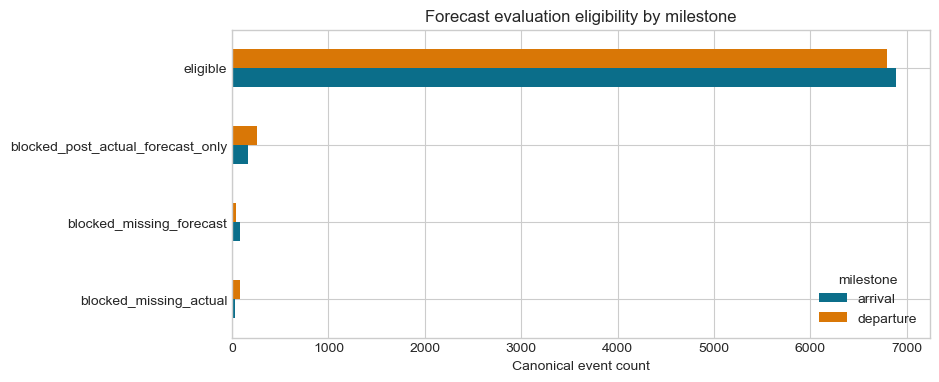

In [5]:
status_chart = status_summary.pivot(index='evaluation_status', columns='milestone', values='canonical_events').fillna(0)
ax = status_chart.plot.barh(figsize=(9, 4), color=['#0b6e8a', '#d97706'])
ax.set_title('Forecast evaluation eligibility by milestone')
ax.set_xlabel('Canonical event count')
ax.set_ylabel('')
figure = ax.get_figure()
buffer = BytesIO()
figure.savefig(buffer, format='png', bbox_inches='tight')
plt.close(figure)
image_data = b64encode(buffer.getvalue()).decode()
display(HTML(f'<img alt="Grouped horizontal bar chart of forecast evaluation eligibility for arrival and departure milestones." src="data:image/png;base64,{image_data}">'))

## 2. Forecast-quality scorecard

Coverage uses canonical events with an actual timestamp as the denominator. Error metrics use only forecasts recorded before or at that actual timestamp.

In [6]:
eligible = evaluation.query("evaluation_status == 'eligible'").copy()

population = evaluation.groupby('milestone').agg(
    canonical_events=('canonical_event_id', 'size'),
    actual_events=('evaluation_status', lambda values: values.ne('blocked_missing_actual').sum()),
    eligible_forecasts=('evaluation_status', lambda values: values.eq('eligible').sum()),
)
accuracy = eligible.groupby('milestone').agg(
    median_absolute_error_hours=('absolute_error_hours', 'median'),
    p90_absolute_error_hours=('absolute_error_hours', lambda values: values.quantile(0.90)),
    median_signed_error_hours=('signed_error_hours', 'median'),
    median_lead_time_hours=('lead_time_hours', 'median'),
    within_6_hours=('absolute_error_hours', lambda values: values.le(6).mean()),
    within_12_hours=('absolute_error_hours', lambda values: values.le(12).mean()),
    within_24_hours=('absolute_error_hours', lambda values: values.le(24).mean()),
)
scorecard = population.join(accuracy)
scorecard['forecast_coverage'] = scorecard['eligible_forecasts'] / scorecard['actual_events']
display(scorecard[
    [
        'canonical_events', 'actual_events', 'eligible_forecasts', 'forecast_coverage',
        'median_absolute_error_hours', 'p90_absolute_error_hours', 'median_signed_error_hours',
        'median_lead_time_hours', 'within_6_hours', 'within_12_hours', 'within_24_hours',
    ]
].style.format({
    'canonical_events': '{:,.0f}',
    'actual_events': '{:,.0f}',
    'eligible_forecasts': '{:,.0f}',
    'forecast_coverage': '{:.2%}',
    'median_absolute_error_hours': '{:.2f}',
    'p90_absolute_error_hours': '{:.2f}',
    'median_signed_error_hours': '{:.2f}',
    'median_lead_time_hours': '{:.2f}',
    'within_6_hours': '{:.2%}',
    'within_12_hours': '{:.2%}',
    'within_24_hours': '{:.2%}',
}))

,canonical_events,actual_events,eligible_forecasts,forecast_coverage,median_absolute_error_hours,p90_absolute_error_hours,median_signed_error_hours,median_lead_time_hours,within_6_hours,within_12_hours,within_24_hours
milestone,,,,,,,,,,,
arrival,"7,172","7,140","6,893",96.54%,0.08,1.50,0.00,93.75,98.43%,99.41%,99.85%
departure,"7,172","7,095","6,799",95.83%,0.15,2.00,0.00,90.52,96.59%,98.25%,99.37%


## 3. Error by forecast lead time

Lead-time bands describe when the retained forecast was recorded relative to the actual milestone. A non-monotonic pattern must be treated as a source-semantics finding, not evidence that longer-range forecasts are inherently better.

In [7]:
lead_labels = ['<24 hours', '24–72 hours', '3–7 days', '7+ days']
eligible['lead_time_band'] = pd.cut(
    eligible['lead_time_hours'],
    bins=[-1, 24, 72, 168, float('inf')],
    labels=lead_labels,
)
lead_time_summary = (
    eligible.groupby(['milestone', 'lead_time_band'], observed=True, as_index=False)
    .agg(
        eligible_forecasts=('canonical_event_id', 'size'),
        median_absolute_error_hours=('absolute_error_hours', 'median'),
        p90_absolute_error_hours=('absolute_error_hours', lambda values: values.quantile(0.90)),
    )
)
display(lead_time_summary.style.format({
    'eligible_forecasts': '{:,.0f}',
    'median_absolute_error_hours': '{:.2f}',
    'p90_absolute_error_hours': '{:.2f}',
}))

,milestone,lead_time_band,eligible_forecasts,median_absolute_error_hours,p90_absolute_error_hours
0,arrival,<24 hours,"2,259",0.25,1.75
1,arrival,24–72 hours,"1,050",0.66,3.58
2,arrival,3–7 days,391,0.25,3.70
3,arrival,7+ days,"3,193",0.00,0.13
4,departure,<24 hours,"2,455",0.17,1.75
5,departure,24–72 hours,798,0.58,8.10
6,departure,3–7 days,451,1.00,11.75
7,departure,7+ days,"3,095",0.10,0.30



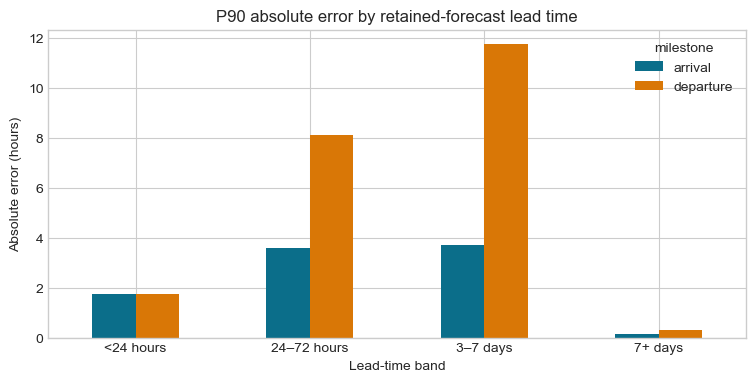

In [8]:
lead_chart = lead_time_summary.pivot(index='lead_time_band', columns='milestone', values='p90_absolute_error_hours').reindex(lead_labels)
ax = lead_chart.plot.bar(figsize=(9, 4), color=['#0b6e8a', '#d97706'])
ax.set_title('P90 absolute error by retained-forecast lead time')
ax.set_xlabel('Lead-time band')
ax.set_ylabel('Absolute error (hours)')
ax.tick_params(axis='x', rotation=0)
figure = ax.get_figure()
buffer = BytesIO()
figure.savefig(buffer, format='png', bbox_inches='tight')
plt.close(figure)
image_data = b64encode(buffer.getvalue()).decode()
display(HTML(f'<img alt="Grouped bar chart of arrival and departure P90 absolute error across four forecast lead-time bands." src="data:image/png;base64,{image_data}">'))

## 4. Segment review and source-level exceptions

Port comparisons are limited to segments with at least 50 eligible forecasts. This threshold is a reporting guard against unstable small-sample comparisons.

In [9]:
port_summary = (
    eligible.groupby(['milestone', 'port_code'], as_index=False)
    .agg(
        eligible_forecasts=('canonical_event_id', 'size'),
        median_absolute_error_hours=('absolute_error_hours', 'median'),
        p90_absolute_error_hours=('absolute_error_hours', lambda values: values.quantile(0.90)),
    )
    .query('eligible_forecasts >= 50')
    .sort_values(['milestone', 'eligible_forecasts'], ascending=[True, False])
)
display(port_summary.groupby('milestone').head(10).style.format({
    'eligible_forecasts': '{:,.0f}',
    'median_absolute_error_hours': '{:.2f}',
    'p90_absolute_error_hours': '{:.2f}',
}))

,milestone,port_code,eligible_forecasts,median_absolute_error_hours,p90_absolute_error_hours
6,arrival,FIHEL,"1,737",0.03,0.34
25,arrival,FIMHQ,692,0.00,0.15
22,arrival,FILAN,606,0.00,0.03
20,arrival,FIKTK,552,0.67,4.33
7,arrival,FIHKO,332,0.17,0.50
39,arrival,FITKU,314,0.00,0.67
26,arrival,FINLI,313,0.00,0.92
35,arrival,FISKV,262,0.75,4.11
2,arrival,FIECK,259,0.00,0.03
34,arrival,FIRAU,235,0.67,3.17


In [10]:
exception_summary = (
    evaluation.query("evaluation_status != 'eligible'")
    .groupby(['milestone', 'evaluation_status'], as_index=False)
    .agg(canonical_events=('canonical_event_id', 'size'))
    .sort_values(['milestone', 'canonical_events'], ascending=[True, False])
)

largest_errors = (
    eligible.nlargest(10, 'absolute_error_hours')
    [[
        'canonical_event_id', 'milestone', 'port_code', 'forecast_source',
        'forecast_recorded_time', 'forecast_time', 'actual_time',
        'signed_error_hours', 'absolute_error_hours', 'source_chunk', 'response_index', 'area_sequence',
    ]]
)

display(exception_summary)
display(largest_errors)

,milestone,evaluation_status,canonical_events
2,arrival,blocked_post_actual_forecast_only,168
1,arrival,blocked_missing_forecast,79
0,arrival,blocked_missing_actual,32
5,departure,blocked_post_actual_forecast_only,255
3,departure,blocked_missing_actual,77
4,departure,blocked_missing_forecast,41


,canonical_event_id,milestone,port_code,forecast_source,forecast_recorded_time,forecast_time,actual_time,signed_error_hours,absolute_error_hours,source_chunk,response_index,area_sequence
248,04f9345e18e2c03c,arrival,FISKV,Agent,2025-02-28 07:09:53+00:00,2026-02-02 02:17:00+00:00,2025-03-02 06:30:00+00:00,-8083.783333,8083.783333,port_calls__20250302T000000Z__20250303T000000Z...,54,1
2640,303fa33ce09c764f,arrival,FISKV,Agent,2025-01-20 07:47:29+00:00,2025-05-21 16:00:00+00:00,2025-01-21 21:15:00+00:00,-2874.750000,2874.750000,port_calls__20250121T000000Z__20250122T000000Z...,38,1
1925,2456f674ee7100ba,departure,FINLI,Agent,2025-02-24 12:34:28+00:00,2025-04-30 20:00:00+00:00,2025-02-28 13:10:00+00:00,-1470.833333,1470.833333,port_calls__20250228T000000Z__20250301T000000Z...,59,1
9339,a7d159c6a1806f8c,departure,FITKU,Agent,2025-01-23 16:58:00+00:00,2025-01-31 10:00:00+00:00,2025-03-31 08:20:00+00:00,1414.333333,1414.333333,port_calls__20250123T000000Z__20250124T000000Z...,76,1
11719,d289b08b1a773f48,departure,FISTR,Agent,2025-01-17 06:57:14+00:00,2025-01-31 15:00:00+00:00,2025-03-31 09:00:00+00:00,1410.000000,1410.000000,port_calls__20250117T000000Z__20250118T000000Z...,76,1
10509,bc5c97e22fffef57,departure,FIPAR,Agent,2025-02-06 13:46:46+00:00,2025-02-28 08:00:00+00:00,2025-04-10 14:10:00+00:00,990.166667,990.166667,port_calls__20250207T000000Z__20250208T000000Z...,82,1
5389,6161b38eb1fbe61e,departure,FITOR,Agent,2025-04-03 19:57:31+00:00,2025-04-14 10:00:00+00:00,2025-04-04 10:02:00+00:00,-239.966667,239.966667,port_calls__20250326T000000Z__20250327T000000Z...,65,1
8422,979f60ca627b0909,arrival,FISKV,Agent,2025-01-01 18:11:50+00:00,2025-01-10 22:01:00+00:00,2025-01-02 18:48:00+00:00,-195.216667,195.216667,port_calls__20250102T000000Z__20250103T000000Z...,37,1
6787,7aca4233857eed03,departure,FIANK,Agent,2025-01-07 21:00:39+00:00,2025-01-13 18:00:00+00:00,2025-01-08 04:00:00+00:00,-134.000000,134.000000,port_calls__20250107T000000Z__20250108T000000Z...,72,1
12429,df2d077a3d2312e1,departure,FINLI,Agent,2025-02-26 09:50:59+00:00,2025-03-11 06:00:00+00:00,2025-03-07 15:10:00+00:00,-86.833333,86.833333,port_calls__20250218T000000Z__20250219T000000Z...,43,1


## Findings and operational interpretation

- Arrival evaluation retains 6,893 forecasts from 7,140 canonical events with an actual arrival (96.54% coverage). Median absolute error is 0.08 hours and P90 is 1.50 hours.
- Departure evaluation retains 6,799 forecasts from 7,095 canonical events with an actual departure (95.83% coverage). Median absolute error is 0.15 hours and P90 is 2.00 hours.
- The point-in-time guard blocks 168 arrival forecasts and 255 departure forecasts whose recorded timestamp is after the actual milestone. Including them would introduce look-ahead leakage.
- The lead-time result is non-monotonic: the retained forecasts recorded seven or more days before actual are unusually close to actual. This may reflect source update semantics or operational schedule conventions and should be investigated before treating the values as predictive performance.
- The appropriate monitoring action is to track coverage, post-actual leakage, error distribution, and segment sample size together. A low aggregate error alone does not establish model quality.

## Limits

- This evaluates the retained ETA/ETD fields in one public operational source. It does not evaluate a Portcast model or any proprietary prediction engine.
- The API snapshot does not provide a complete history of forecast revisions, so this notebook cannot measure how accuracy changes across successive updates for the same event.
- Port-level differences are descriptive and are not port, carrier, or service-level rankings.
- No customer cost, delay prevention, detention, demurrage, or business impact is inferred from these fields.